# Look at the fine-tuned gatortron on the additional snippets

annotated by Aish and Amy. 

1. look at inter coder correlation (ICC)
2. Load the fine-tuned model
3. Print prediction and compare with original testing set (see if comparible)

In [1]:
import pandas as pd

rater1 = pd.read_csv('additional_testing_annotations/manual_annotation_sampled_100_snippets_Aish.csv')
rater2 = pd.read_csv('additional_testing_annotations/manual_annotation_sampled_100_snippets_Amy.csv')
rater1 = rater1.rename(columns={'label': 'label_rater1'})
rater2 = rater2.rename(columns={'label': 'label_rater2'})


from sklearn.metrics import cohen_kappa_score
df_test = rater1.merge(rater2[['uid', 'label_rater2']], on='uid')
kappa = cohen_kappa_score(df_test['label_rater1'], df_test['label_rater2'])
print(f"Cohen's Kappa: {kappa:.3f}")
df_test.head()


Cohen's Kappa: 0.745


,Date,Condition,Relevant Snippets,uid,label_rater1,label_rater2
0,2024-05-21T16:53:00,RA,scular blockers steroidal sesame sunflower oil...,27424,1,1
1,2021-08-02T00:00:00,AS,etanercept mmf and azathioprine and was doing ...,42736,1,1
2,2018-09-06T13:00:00,SSc,laquenil 200 mg tablet l acidophilus / l rhamn...,1018,4,1
3,2018-06-28T10:30:00,SjS,ic po take 1 tab by mouth every day magnesium ...,13748,4,1
4,2023-07-24T18:47:00,SSc,opics alcohol use : yes comment : socially onc...,4602,4,4


In [2]:
# look at snippets with disagreement
disagreement_df = df_test[df_test['label_rater1'] != df_test['label_rater2']]
print(f"Number of disagreements: {len(disagreement_df)}")
print([i for i in disagreement_df[['Relevant Snippets']].values])
print([i for i in disagreement_df[['label_rater2']].values])
print([i for i in disagreement_df[['label_rater1']].values])


Number of disagreements: 15
[array(['laquenil 200 mg tablet l acidophilus / l rhamnosus probiotic po magnesium po medical #### #### marijuana #### #### as endorsed by physician nifedipine procardia xl 30 mg extended release table'],
      dtype=object), array(['ic po take 1 tab by mouth every day magnesium po take 1 tab by mouth every day medical #### #### marijuana #### #### as endorsed by physician #### cbd #### oil sublingual at hs prn nifedipine procardia xl 30 mg extended rel'],
      dtype=object), array(['medications 1 systane ultra prescribed 4 times daily 2 mirena iud x 3 years 3 #### cbd #### oil x 2 mos no help past surgical history : procedure laterality date hx appen'],
      dtype=object), array(['sed and states she still has feelings of suicide but not active plan recived tms today but missed #### cbd #### because she missed a part of it remains isolative in mileu wearing headphones and knittin'],
      dtype=object), array(['specific gravity 02 / 14 / 2019 normal normal

In [3]:
import transformers
from transformers import BertModel, BertTokenizer, get_linear_schedule_with_warmup
import torch
from torch.optim import AdamW
import numpy as np
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from collections import defaultdict
from textwrap import wrap
import math
from sklearn.model_selection import StratifiedKFold
from typing import Dict, List
from sklearn.metrics import roc_auc_score

from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from tqdm import tqdm
import os

%matplotlib inline
%config InlineBackend.figure_format='retina'

sns.set(style='whitegrid', palette='muted', font_scale=1.2)


rcParams['figure.figsize'] = 12, 8

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device


2025-11-21 19:31:54.468754: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-21 19:31:54.490802: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-21 19:31:54.863525: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


device(type='cuda', index=0)

In [4]:

# rename to label

df_test = df_test.rename(columns={"label_rater1": "label", "Relevant Snippets": "text"})
df_test = df_test[["text", "label"]]
df_test['label'] = df_test['label']-1
print(df_test.columns)
class_label_names = ['Not A True Mention', 'Denial of Use', 'Positive Past Use', 'Positive Current Use']

Index(['text', 'label'], dtype='object')


Text(0.5, 0, 'label')

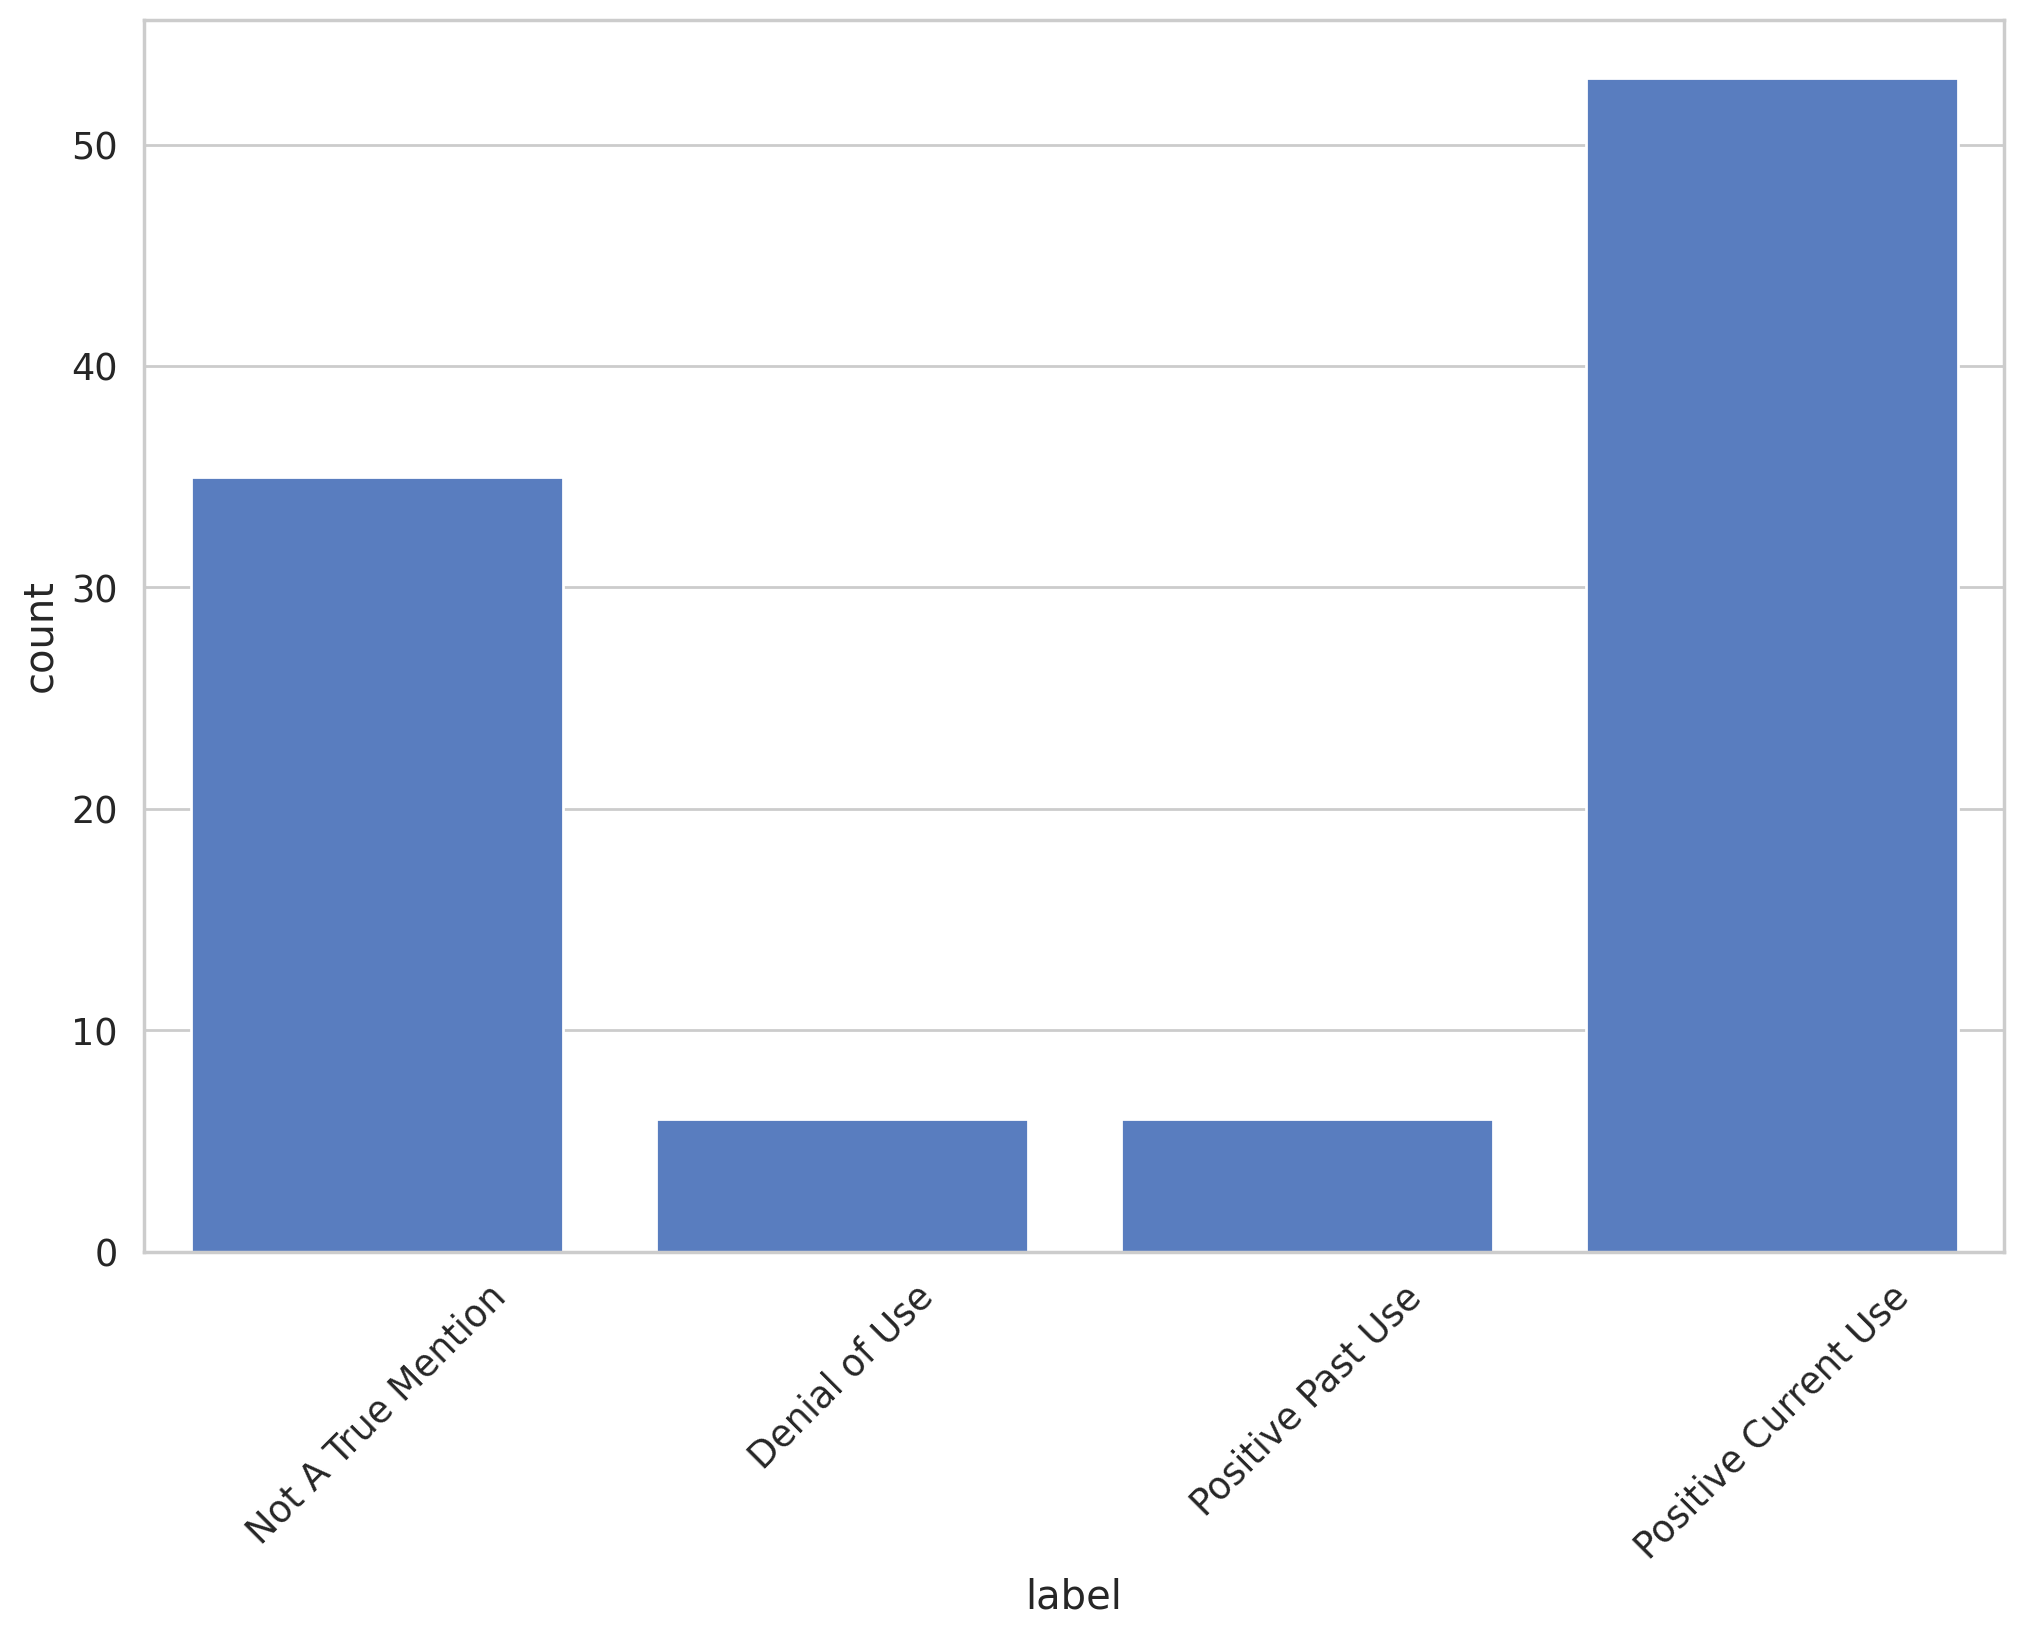

In [5]:
# distribution of the four class in sentiment
sns.barplot(x=df_test.label.value_counts().index, y=df_test.label.value_counts())
plt.xticks(ticks=range(len(class_label_names)), labels=class_label_names, rotation=45)
plt.xlabel('label')

In [6]:
from transformers import AutoTokenizer, AutoModel
# PRE_TRAINED_MODEL_NAME="roberta-large-mnli"
tokenizer = AutoTokenizer.from_pretrained('LLMs/gatortron-base', local_files_only=True)


In [7]:
tokenizer.sep_token, tokenizer.sep_token_id


('[SEP]', 102)

In [8]:
tokenizer.cls_token, tokenizer.cls_token_id


('[CLS]', 101)

In [9]:
tokenizer.pad_token, tokenizer.pad_token_id


('[PAD]', 0)

In [10]:
tokenizer.unk_token, tokenizer.unk_token_id


('[UNK]', 100)

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


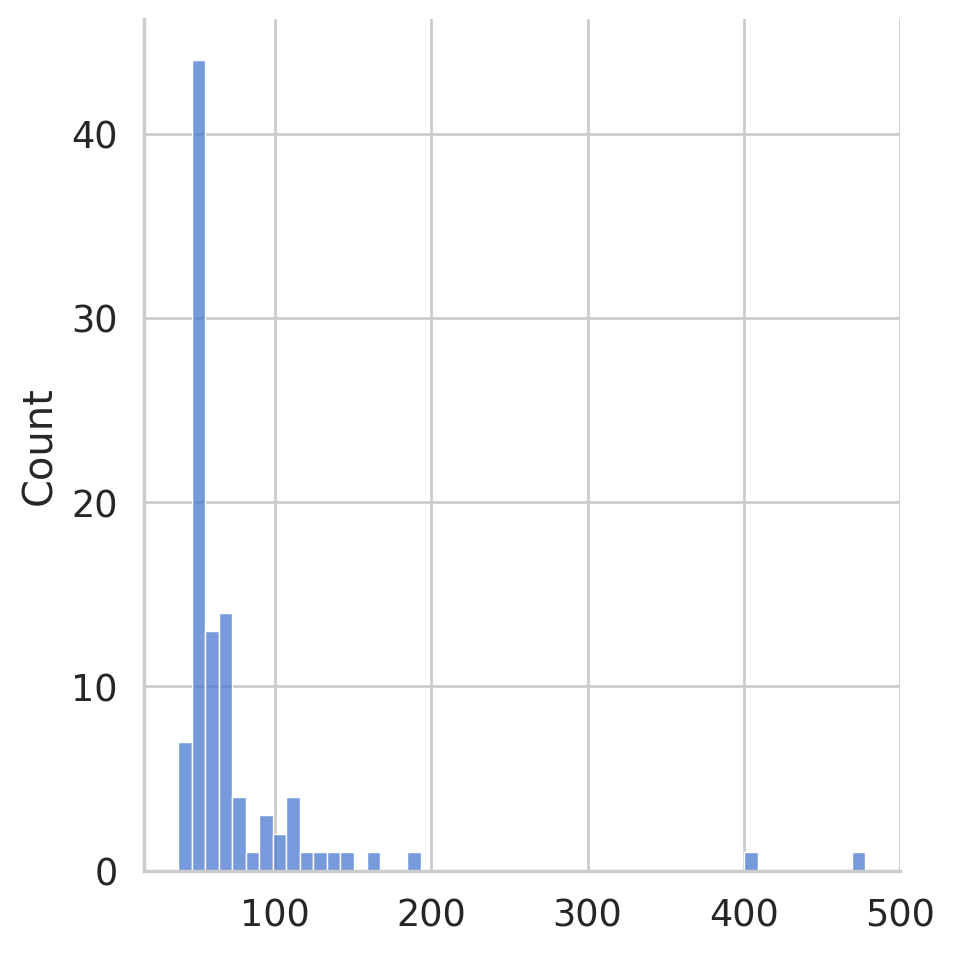

In [11]:
token_lens=[]
for txt in df_test.text:
  tokens=tokenizer.encode(txt,max_length=512)
  token_lens.append(len(tokens))
sns.displot(token_lens)

In [12]:
class CannabisClassData(Dataset):
  def __init__(self, text, label, tokenizer, max_len):
    self.text=text
    self.label=label
    self.tokenizer=tokenizer
    self.max_len=max_len
    
  def __len__(self):
    return len(self.text)
  
  def __getitem__(self,item):
    text= str(self.text[item])
    label=self.label[item]
    encoding=self.tokenizer.encode_plus(
    text,
    max_length=self.max_len,
    add_special_tokens=True,
    # pad_to_max_length=True,
    truncation =True,
    return_attention_mask=True,
    return_token_type_ids=False,
    return_tensors='pt'
    )
    return{
        'text':text,
        'input_ids': encoding['input_ids'].flatten(),
        'attention_mask': encoding['attention_mask'].flatten(),
        'label':torch.tensor(label,dtype=torch.long)
    }

    


In [13]:
from torch.nn.utils.rnn import pad_sequence
def collate_fn(batch):
    input_ids = [b["input_ids"] for b in batch]
    attention_mask = [b["attention_mask"] for b in batch]
    labels = [b["label"] for b in batch]
    

    input_ids = pad_sequence(input_ids, batch_first=True, padding_value=tokenizer.pad_token_id)
    attention_mask = pad_sequence(attention_mask, batch_first=True, padding_value=0)
    labels = torch.tensor(labels)

    return {"input_ids": input_ids, "attention_mask": attention_mask, "label": labels}


def create_data_loader(df, tokenizer, max_len, batch_size, collate_fn=collate_fn):
  ds = CannabisClassData(
    text=df.text.to_numpy(),
    label=df.label.to_numpy(),
    tokenizer=tokenizer,
    max_len=max_len
  )
  return DataLoader(
    ds,
    batch_size=batch_size,
    num_workers=0,
    collate_fn=collate_fn
  )
     

In [14]:
class CannabisClassifier(nn.Module):
  def __init__(self,PRE_TRAINED_MODEL_NAME,n_classes, dropout_rate=0.3):
    super(CannabisClassifier,self).__init__()
    self.bert=AutoModel.from_pretrained(PRE_TRAINED_MODEL_NAME, local_files_only=True)
    self.drop=nn.Dropout(p=dropout_rate)
    self.out=nn.Linear(self.bert.config.hidden_size,n_classes)
    self.softmax=nn.Softmax(dim=1)
  def forward(self,input_ids,attention_mask):
    _,pooled_output=self.bert(
      input_ids=input_ids,
      attention_mask=attention_mask,
      return_dict=False
    )
    output=self.drop(pooled_output)
    output=self.out(output)
    #return self.softmax(output)
    return nn.LogSoftmax(dim=1)(output)

In [15]:
class CannabisClassifierFrozenBackbone(nn.Module):
    def __init__(self, PRE_TRAINED_MODEL_NAME, n_classes, dropout_rate=0.1):
        super(CannabisClassifierFrozenBackbone, self).__init__()
        self.bert = AutoModel.from_pretrained(PRE_TRAINED_MODEL_NAME)
        for param in self.bert.parameters():
            param.requires_grad = False
        hidden_size = self.bert.config.hidden_size
        self.drop=nn.Dropout(p=dropout_rate)
        self.out = nn.Linear(hidden_size, n_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, input_ids, attention_mask):
        _, pooled_output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=False
        )
        output=self.drop(pooled_output)
        output=self.out(output)
        #return self.softmax(output)
        return nn.LogSoftmax(dim=1)(output)

In [16]:
import torch

def eval_model(model, data_loader, loss_fn, device):
    model.eval()  # set model to evaluation mode
    model.to(device)
    
    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for d in data_loader:
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            labels = d["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = loss_fn(outputs, labels)
            total_loss += loss.item()

            # predictions = argmax over class dimension
            preds = torch.argmax(outputs, dim=1)
            correct_predictions += torch.sum(preds == labels).item()
            total_samples += labels.size(0)

    avg_loss = total_loss / len(data_loader)
    accuracy = correct_predictions / total_samples

    return avg_loss, accuracy


In [17]:
def get_predictions(model, data_loader):
  model = model.eval()
  model.to(device)
  
  predictions = []
  prediction_probs = []
  real_values = []

  with torch.no_grad():
    for d in data_loader:
      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      label = d["label"].to(device)

      outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
      )
      _, preds = torch.max(outputs, dim=1)

      probs = F.softmax(outputs, dim=1)

      predictions.extend(preds)
      prediction_probs.extend(probs)
      real_values.extend(label)

  predictions = torch.stack(predictions).cpu()
  prediction_probs = torch.stack(prediction_probs).cpu()
  real_values = torch.stack(real_values).cpu()

  return predictions, prediction_probs, real_values

In [18]:
# — rebuild best model (train + val) —————————————————

import json

PRE_TRAINED_MODEL_dir='LLMs/gatortron-base'
params = json.load(open("output/gatortron-base_finetune_status/best_model/best_model_params.json"))
best_state_path = f"output/gatortron-base_finetune_status/best_model/best_model_state_tune-{params['tune_mode']}.bin"
best_state = torch.load(best_state_path, map_location=device)
tune_mode = params.get("tune_mode")
dropout_rate = params.get("dropout", 0.3)
if tune_mode == "full":
    model = CannabisClassifier(
        PRE_TRAINED_MODEL_NAME=PRE_TRAINED_MODEL_dir,
        n_classes=len(np.unique(df_test.label)),
        dropout_rate=dropout_rate,
    )
else:
    model = CannabisClassifierFrozenBackbone(
        PRE_TRAINED_MODEL_NAME=PRE_TRAINED_MODEL_dir,
        n_classes=len(np.unique(df_test.label)),
        dropout_rate=params["dropout"],
    )


model.load_state_dict(best_state)
model.eval()
loss_fn=nn.CrossEntropyLoss().to(device)
# — final **test** evaluation ————————————————————
test_loader = create_data_loader(df_test, tokenizer, params['max_len'], 1)
test_loss, test_acc = eval_model(
    model,
    test_loader,
    loss_fn,
    device
)


print(f"\n🎯  FINAL TEST — ACC={test_acc:.3f} LOSS={test_loss:.3f}")



🎯  FINAL TEST — ACC=0.890 LOSS=0.660


In [19]:
y_pred, y_pred_probs, y_test = get_predictions(
  model,
  test_loader
)

In [20]:

print(classification_report(y_test, y_pred, target_names=class_label_names))
    

                      precision    recall  f1-score   support

  Not A True Mention       0.83      0.97      0.89        35
       Denial of Use       0.50      0.17      0.25         6
   Positive Past Use       0.75      0.50      0.60         6
Positive Current Use       0.96      0.96      0.96        53

            accuracy                           0.89       100
           macro avg       0.76      0.65      0.68       100
        weighted avg       0.88      0.89      0.87       100

